In [176]:
# Checking spatial convergence and rayleigh damping for the gap flow.

In [177]:
import numpy as np
import scipy
from netCDF4 import Dataset
from matplotlib import pyplot as plt
import argparse
import metpy
import metpy.calc as mpcalc
from metpy.units import units
import xarray as xr
import matplotlib.colors as colors
import matplotlib
import copy
import cmaps

In [178]:
def z_interp(h, field_vals_all, lon, lat, z_val):
    field_vals = np.zeros((len(lat), len(lon)))
    for i in np.arange(len(lat)):
        for j in np.arange(len(lon)):
            if h[-1,i,j] > z_val:
                # This value is inside the topography
                field_vals[i,j] = np.nan
            else:
                # Find indices either side of this value
                low_idx = np.where(h[:,i,j] < z_val)[0][0]
                high_idx = np.where(h[:,i,j] > z_val)[0][-1]

                # Compute weightings
                weight_low = (z_val - h[low_idx,i,j])/(h[high_idx,i,j] - h[low_idx,i,j])
                weight_high = 1. - weight_low

                # Compute and store value
                field_vals[i,j] = weight_low*field_vals_all[low_idx, i, j] + weight_high*field_vals_all[high_idx, i, j]
    return field_vals

def cubic_z_interp(h, field_vals_all, lon, lat, z_val):
    # Now make cubic interpolation coefficients for each grid staggering
    w3_coeffs = [np.zeros_like(h) for _ in w3_levels]
    w3_coeffs[0] = (
        (height_plot - height_w3[1]) * (height_plot - height_w3[2])
        * (height_plot - height_w3[3])
    ) / (
        (height_w3[0] - height_w3[1]) * (height_w3[0] - height_w3[2])
        * (height_w3[0] - height_w3[3])
    )
    w3_coeffs[1] = (
        (height_plot - height_w3[0]) * (height_plot - height_w3[2])
        * (height_plot - height_w3[3])
    ) / (
        (height_w3[1] - height_w3[0]) * (height_w3[1] - height_w3[2])
        * (height_w3[1] - height_w3[3])
    )
    w3_coeffs[2] = (
        (height_plot - height_w3[0]) * (height_plot - height_w3[1])
        * (height_plot - height_w3[3])
    ) / (
        (height_w3[2] - height_w3[0]) * (height_w3[2] - height_w3[1])
        * (height_w3[2] - height_w3[3])
    )
    w3_coeffs[3] = (
        (height_plot - height_w3[0]) * (height_plot - height_w3[1])
        * (height_plot - height_w3[2])
    ) / (
        (height_w3[3] - height_w3[0]) * (height_w3[3] - height_w3[1])
        * (height_w3[3] - height_w3[2])
    )
    wth_coeffs = [np.zeros_like(height_surface) for _ in wth_levels]
    wth_coeffs[0] = (
        (height_plot - height_wth[1]) * (height_plot - height_wth[2])
        * (height_plot - height_wth[3])
    ) / (
        (height_wth[0] - height_wth[1]) * (height_wth[0] - height_wth[2])
        * (height_wth[0] - height_wth[3])
    )
    wth_coeffs[1] = (
        (height_plot - height_wth[0]) * (height_plot - height_wth[2])
        * (height_plot - height_wth[3])
    ) / (
        (height_wth[1] - height_wth[0]) * (height_wth[1] - height_wth[2])
        * (height_wth[1] - height_wth[3])
    )
    wth_coeffs[2] = (
        (height_plot - height_wth[0]) * (height_plot - height_wth[1])
        * (height_plot - height_wth[3])
    ) / (
        (height_wth[2] - height_wth[0]) * (height_wth[2] - height_wth[1])
        * (height_wth[2] - height_wth[3])
    )
    wth_coeffs[3] = (
        (height_plot - height_wth[0]) * (height_plot - height_wth[1])
        * (height_plot - height_wth[2])
    ) / (
        (height_wth[3] - height_wth[0]) * (height_wth[3] - height_wth[1])
        * (height_wth[3] - height_wth[2])
    )
    w2h_coeffs = [np.zeros_like(height_surface) for _ in w3_levels]
    w2h_coeffs[0] = (
        (height_plot - height_w2h[1]) * (height_plot - height_w2h[2])
        * (height_plot - height_w2h[3])
    ) / (
        (height_w2h[0] - height_w2h[1]) * (height_w2h[0] - height_w2h[2])
        * (height_w2h[0] - height_w2h[3])
    )
    w2h_coeffs[1] = (
        (height_plot - height_w2h[0]) * (height_plot - height_w2h[2])
        * (height_plot - height_w2h[3])
    ) / (
        (height_w2h[1] - height_w2h[0]) * (height_w2h[1] - height_w2h[2])
        * (height_w2h[1] - height_w2h[3])
    )
    w2h_coeffs[2] = (
        (height_plot - height_w2h[0]) * (height_plot - height_w2h[1])
        * (height_plot - height_w2h[3])
    ) / (
        (height_w2h[2] - height_w2h[0]) * (height_w2h[2] - height_w2h[1])
        * (height_w2h[2] - height_w2h[3])
    )
    w2h_coeffs[3] = (
        (height_plot - height_w2h[0]) * (height_plot - height_w2h[1])
        * (height_plot - height_w2h[2])
    ) / (
        (height_w2h[3] - height_w2h[0]) * (height_w2h[3] - height_w2h[1])
        * (height_w2h[3] - height_w2h[2])
    )

In [179]:
rot = False

dycore1 = 'CAM-SE'
dycore2 = 'CAM-FV3'
dycore3 = 'CAM-MPAS'
dycore4 = 'GungHo'

res1 = 'se_ne60'
res2 = 'fv3_C192'
res3 = 'mpasa60'

test_name_start1 = 'cam_6_4_100'
test_name_start2 = 'cam_6_4_070_horiz_mount_flow'
test_name_start3 = 'cam_6_4_080_paper_six'


#lev_no1 = 'ztop20km_L57'
#extra_name1 = 'tau_1_10'
#extra_name1 = 'tau_1_10_nsplit4'
#extra_name1 = 'tau_1_10_nsplit4_visc_subcyc_1'
lev_no1 = 'ztop20km_L57_new_RF'
extra_name1 = 'tau_200s_diff_2x_weaker'
#extra_name1 = 'tau_0s'

#lev_no2 = 'ztop20km_L57'
#extra_name2 = 'tau_1_10_no_vortdamp'
#extra_name2 = 'tau_1_10_no_vortdamp_ksplit2'
#extra_name2 = 'tau_1_10_no_vortdamp_ksplit2_hord5'
lev_no2 = 'ztop20km_L57_new_RF'
extra_name2 = 'tau200s'
#extra_name2 = 'tau200s_taumix90s'
#extra_name2 = 'tau100s'
#extra_name2 = 'tau10s'

#lev_no3 = 'L20km_L57'
#extra_name3 = 'tau_1_10_new_vgrid'
lev_no3 = 'L20km_L57_new_RF'
extra_name3 = 'tau200s'


case1 = f'{test_name_start1}_{res1}_{lev_no1}'
case2 = f'{test_name_start2}_{res2}_{lev_no2}'
case3 = f'{test_name_start3}_{res3}_{lev_no3}'

# Compare three files
if rot:
    nc_file1 = f'{case1}.cam.h0i.0001-01-01-00000_gap_with_rot_{extra_name1}'
    nc_file2 = f'{case2}.cam.h0i.0001-01-01-00000_gap_with_rot_{extra_name2}'
    nc_file3 = f'{case3}.cam.h0i.0001-01-01-00000_gap_with_rot_{extra_name3}'
    nc_file4 = f'dcmip_lonlat_mountain_gap'
    #nc_file4 = f'dcmip_lonlat_mountain_gap_trad_coriolis'
else:
    nc_file1 = f'{case1}.cam.h0i.0001-01-01-00000_gap_omega0_{extra_name1}'
    nc_file2 = f'{case2}.cam.h0i.0001-01-01-00000_gap_omega0_{extra_name2}'
    nc_file3 = f'{case3}.cam.h0i.0001-01-01-00000_gap_omega0_{extra_name3}'
    nc_file4 = f'dcmip_lonlat_mountain_gap_no_rotation'
    #nc_file4 = f'dcmip_lonlat_mountain_gap_no_rotation_trad_coriolis'

nc_file1 = nc_file1 + '.nc'
nc_file2 = nc_file2 + '.regrid.0.5x0.5.nc'  # FV3 needs regridding
nc_file3 = nc_file3 + '.regrid.0.5x0.5.nc'  # MPAS needs regridding
nc_file4 = nc_file4 + '.nc'

print(nc_file1)
print(nc_file4)

cam_6_4_100_se_ne60_ztop20km_L57_new_RF.cam.h0i.0001-01-01-00000_gap_omega0_tau_200s_diff_2x_weaker.nc
dcmip_lonlat_mountain_gap_no_rotation.nc


In [180]:
run_base = "/glade/derecho/scratch/timand/"

run_path1 = run_base + case1 + '/run/' + nc_file1
run_path2 = run_base + case2 + '/run/' + nc_file2
run_path3 = run_base + case3 + '/run/' + nc_file3
run_path4 = '/glade/u/home/timand/LFRic_results/' + nc_file4

nc1 = Dataset(run_path1)
nc2 = Dataset(run_path2)
nc3 = Dataset(run_path3)
nc4 = Dataset(run_path4)

u = nc4['u'][:]

print(np.shape(u))

(720, 361)


In [181]:
time = nc1['time'][:]
lat = nc1['lat'][:] 
lon = nc1['lon'][:] 

print(np.size(lat), np.size(lon))

361 720


In [182]:
# Specify the size of the lon-lat crop, which
# will be centred around the equator for lat
'''
if rot == True:
    lat_crop_up = 40.
    lat_cent_down = -40.
    lat_ticks = np.linspace(-40.,40.,5)
    
    lon_crop_left = 140.
    lon_crop_right = 280.
    lon_ticks = np.linspace(140, 280, 8)
else:
    lat_crop_up = 50.
    lat_cent_down = -50.
    lat_ticks = np.linspace(-40, 40, 5)

    lon_crop_left = 160.
    lon_crop_right = 280.
    lon_ticks = np.linspace(160, 280, 7)
'''


# Consistent lon lat ranges
lat_crop_up = 40.
lat_cent_down = -40.
lat_ticks = np.linspace(-40.,40.,5)

lon_crop_left = 140.
lon_crop_right = 280.
lon_ticks = np.linspace(140, 280, 8)

lon_inds = np.where((lon <= lon_crop_right) & (lon >= lon_crop_left))[0]
lat_inds = np.where((lat <= lat_crop_up) & (lat >= lat_cent_down))[0]

lat_crop = lat[lat_inds]
lon_crop = lon[lon_inds]

LON, LAT = np.meshgrid(lon_crop, lat_crop)

lon_lfric = lon_inds - 180

print(np.shape(lon_crop))

(281,)


In [183]:
# Time index to compare at
t_idx = 40

# z level to compare at, in m.
# For reference, the Gabersek, Durran paper
# plots at z = 300 m.
z_val = 300

title_size=16
label_size=14
small_size=12

In [184]:
# Interpolations of U and T

U_field_vals1 = z_interp(nc1['Z3'][t_idx, :, lat_inds, lon_inds], nc1['U'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
U_field_vals2 = z_interp(nc2['Z3'][t_idx, :, lat_inds, lon_inds], nc2['U'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
U_field_vals3 = z_interp(nc3['Z3'][t_idx, :, lat_inds, lon_inds], nc3['U'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
U_field_vals4 = np.transpose(nc4['u'][lon_lfric, lat_inds])

T_field_vals1 = z_interp(nc1['Z3'][t_idx, :, lat_inds, lon_inds], nc1['T'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
T_field_vals2 = z_interp(nc2['Z3'][t_idx, :, lat_inds, lon_inds], nc2['T'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
T_field_vals3 = z_interp(nc3['Z3'][t_idx, :, lat_inds, lon_inds], nc3['T'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
T_field_vals4 = np.transpose(nc4['T'][lon_lfric, lat_inds])

print(np.shape(T_field_vals3))
print(np.shape(T_field_vals4))
print(np.shape(LAT))

(160, 281)
(160, 281)
(160, 281)


In [185]:
deg2rad = np.pi/180
T0 = 288
u0 = 10

# Normalised velocity perturbation:
U_field_vals1 = (U_field_vals1 - u0*np.cos(LAT*deg2rad))/(u0*np.cos(LAT*deg2rad))
U_field_vals2 = (U_field_vals2 - u0*np.cos(LAT*deg2rad))/(u0*np.cos(LAT*deg2rad))
U_field_vals3 = (U_field_vals3 - u0*np.cos(LAT*deg2rad))/(u0*np.cos(LAT*deg2rad))
U_field_vals4 = (U_field_vals4 - u0*np.cos(LAT*deg2rad))/(u0*np.cos(LAT*deg2rad))

# Temperature perturbation:
T_field_vals1 = T_field_vals1 - T0
T_field_vals2 = T_field_vals2 - T0
T_field_vals3 = T_field_vals3 - T0
T_field_vals4 = T_field_vals4 - T0

In [186]:
# What are the maximum values AWAY from the mountain??
lon_max_inds = np.where(np.logical_or((lon_crop <= 170),(lon_crop >= 190)))[0]
lfric_max_inds = np.where(np.logical_or((lon_crop <= 170),(lon_crop >= 190)))[0]

se_U_max_crop = U_field_vals1[:,lon_max_inds]
se_T_max_crop = T_field_vals1[:,lon_max_inds]

fv3_U_max_crop = U_field_vals2[:,lon_max_inds]
fv3_T_max_crop = T_field_vals2[:,lon_max_inds]

mpas_U_max_crop = U_field_vals3[:,lon_max_inds]
mpas_T_max_crop = T_field_vals3[:,lon_max_inds]

gungho_U_max_crop = U_field_vals4[:,lfric_max_inds]
gungho_T_max_crop = T_field_vals4[:,lfric_max_inds]

print(f'SE U min {np.min(se_U_max_crop):.2f}, U max {np.max(se_U_max_crop):.2f}')
print(f'SE T min {np.min(se_T_max_crop):.2f}, U max {np.max(se_T_max_crop):.2f} \n')

print(f'FV3 U min {np.min(fv3_U_max_crop):.2f}, U max {np.max(fv3_U_max_crop):.2f}')
print(f'FV3 T min {np.min(fv3_T_max_crop):.2f}, U max {np.max(fv3_T_max_crop):.2f} \n')

print(f'MPAS U min {np.min(mpas_U_max_crop):.2f}, U max {np.max(mpas_U_max_crop):.2f}')
print(f'MPAS T min {np.min(mpas_T_max_crop):.2f}, U max {np.max(mpas_T_max_crop):.2f} \n')

print(f'GungHo U min {np.min(gungho_U_max_crop):.2f}, U max {np.max(gungho_U_max_crop):.2f}')
print(f'GungHo T min {np.min(gungho_T_max_crop):.2f}, U max {np.max(gungho_T_max_crop):.2f} \n')

print(f'GungHo U min {np.min(U_field_vals4):.8f}, U max {np.max(U_field_vals4):.8f}')
print(f'GungHo T min {np.nanmin(T_field_vals4):.8f}, T max {np.nanmax(T_field_vals4):.8f} \n')

SE U min -2.44, U max 1.16
SE T min -5.32, U max 10.67 

FV3 U min -1.96, U max 1.05
FV3 T min -1.97, U max 7.72 

MPAS U min -2.14, U max 1.04
MPAS T min -1.67, U max 7.09 

GungHo U min -2.23, U max 1.69
GungHo T min -2.15, U max 7.43 

GungHo U min -2.24099374, U max 2.16183828
GungHo T min -3.84494019, T max 8.68115234 



min value is -2.4363345768104328
max value is 2.1618382845447557


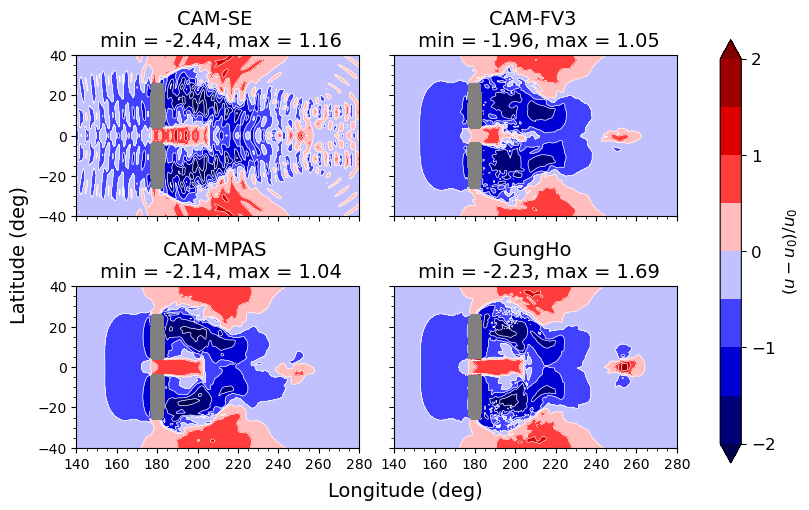

In [187]:
# Plot for U
U_cmap = matplotlib.cm.seismic
#U_cmap = matplotlib.cm.RdYlBu_r
#U_cmap.set_under('k')
#U_cmap.set_over('white')

#U_cmap = cmaps.ncl_default

U_max1 = np.nanmax(U_field_vals1)
U_max2 = np.nanmax(U_field_vals2)
U_max3 = np.nanmax(U_field_vals3)
U_max4 = np.nanmax(U_field_vals4)

U_min1 = np.nanmin(U_field_vals1)
U_min2 = np.nanmin(U_field_vals2)
U_min3 = np.nanmin(U_field_vals3)
U_min4 = np.nanmin(U_field_vals4)

U_maxmax = max(U_max1, U_max2, U_max3, U_max4)
U_minmin = min(U_min1, U_min2, U_min3, U_min4)

print('min value is', U_minmin)
print('max value is', U_maxmax)

#if rot:
#    fig, axes = plt.subplots(2,2, sharey=True, sharex=True, figsize = (8,5), layout="constrained")
#else:
#    fig, axes = plt.subplots(2,2, sharey=True, sharex=True, figsize = (8,6.5), layout="constrained")
fig, axes = plt.subplots(2,2, sharey=True, sharex=True, figsize = (8,5), layout="constrained")
    
(ax1, ax2), (ax3, ax4) = axes

#if rot:
#    U_conts = np.linspace(-2.0, 2.0, 9)
#    tick_range = np.linspace(-2.0, 2.0, 5)
#    norm = colors.TwoSlopeNorm(vmin=-2.0, vcenter=0, vmax=2.0)
#else:
#    U_conts = np.linspace(-2.0, 1.0, 7)
#    tick_range = np.linspace(-2.0, 1.0, 7)
#    norm = colors.TwoSlopeNorm(vmin=-2.0, vcenter=0, vmax=1.0)

# Consistent scales between with/without rotation
U_conts = np.linspace(-2.0, 2.0, 9)
tick_range = np.linspace(-2.0, 2.0, 5)
norm = colors.TwoSlopeNorm(vmin=-2.0, vcenter=0, vmax=2.0)

plot1 = ax1.contourf(LON, LAT, U_field_vals1, levels = U_conts, cmap=U_cmap, norm=norm, extend = 'both')
plot2 = ax2.contourf(LON, LAT, U_field_vals2, levels = U_conts, cmap=U_cmap, norm=norm, extend = 'both')
plot3 = ax3.contourf(LON, LAT, U_field_vals3, levels = U_conts, cmap=U_cmap, norm=norm, extend = 'both')
plot4 = ax4.contourf(LON, LAT, U_field_vals4, levels = U_conts, cmap=U_cmap, norm=norm, extend = 'both')
#plot4 = ax4.contourf(LON, LAT, U_field_vals4)
U_title = 'Normalised velocity perturbation'

# If we want contours overlaid:
ax1.contour(LON, LAT, U_field_vals1, levels = U_conts, linestyles='solid', colors='white', linewidths=0.5, norm=norm, extend = 'both')
ax2.contour(LON, LAT, U_field_vals2, levels = U_conts, linestyles='solid', colors='white', linewidths=0.5, norm=norm, extend = 'both')
ax3.contour(LON, LAT, U_field_vals3, levels = U_conts, linestyles='solid', colors='white', linewidths=0.5, norm=norm, extend = 'both')
ax4.contour(LON, LAT, U_field_vals4, levels = U_conts, linestyles='solid', colors='white', linewidths=0.5, norm=norm, extend = 'both')

for ax in axes.flatten():
    ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(5))
    ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(5))

    ax.set_aspect('equal')
    ax.set_facecolor("grey")

plt.xticks(lon_ticks)
plt.yticks(lat_ticks)

cb = plt.colorbar(plot4, ax=axes, ticks = tick_range, fraction=0.4)
cb.set_label(label=r"$(u - u_0)/u_0$", size=small_size)
cb.ax.tick_params(labelsize=12)

# Overall extrema
#ax1.set_title(f'{dycore1} \n min = {np.round(U_min1,2)}, max = {np.round(U_max1,2)}', size=label_size)
#ax2.set_title(f'{dycore2} \n min = {np.round(U_min2,2)}, max = {np.round(U_max2,2)}', size=label_size)
#ax3.set_title(f'{dycore3} \n min = {np.round(U_min3,2)}, max = {np.round(U_max3,2)}', size=label_size)
#ax4.set_title(f'{dycore4} \n min = {np.round(U_min4,2)}, max = {np.round(U_max4,2)}', size=label_size)

# Extrema away from the mountain
ax1.set_title(f'{dycore1} \n min = {np.min(se_U_max_crop):.2f}, max = {np.max(se_U_max_crop):.2f}', size=label_size)
ax2.set_title(f'{dycore2} \n min = {np.min(fv3_U_max_crop):.2f}, max = {np.max(fv3_U_max_crop):.2f}', size=label_size)
ax3.set_title(f'{dycore3} \n min = {np.min(mpas_U_max_crop):.2f}, max = {np.max(mpas_U_max_crop):.2f}', size=label_size)
ax4.set_title(f'{dycore4} \n min = {np.min(gungho_U_max_crop):.2f}, max = {np.max(gungho_U_max_crop):.2f}', size=label_size)

fig.supylabel('Latitude (deg)', size=label_size)
fig.supxlabel('Longitude (deg)', size=label_size)

# If saving:
savefig = True

if savefig:
    if rot:
        plt.savefig('figures/gap_with_rot_U.png')
    else:
        plt.savefig('figures/gap_omega0_U.png')


min value is -5.315948342814124
max value is 10.673870498495376


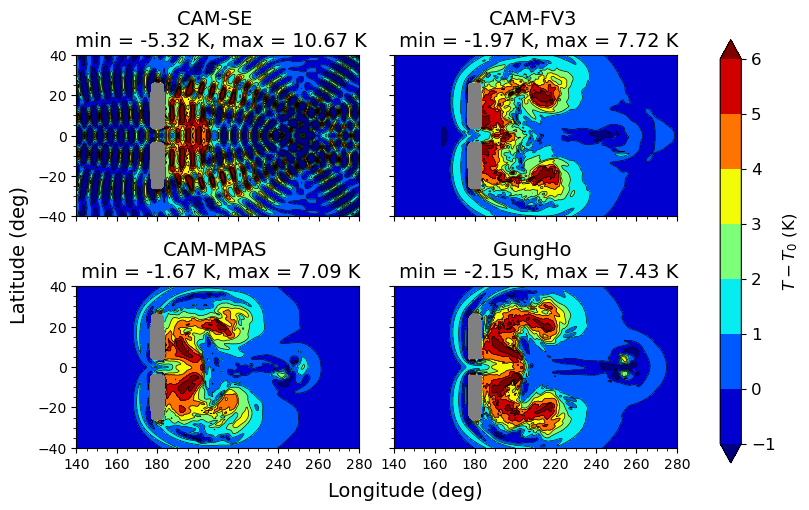

In [188]:
### T plot

T_cmap = copy.copy(matplotlib.cm.jet)
#T_cmap.set_under('k')
#T_cmap.set_over('deep red')

#T_cmap = cmaps.ncl_default

T_max1 = np.nanmax(T_field_vals1)
T_max2 = np.nanmax(T_field_vals2)
T_max3 = np.nanmax(T_field_vals3)
T_max4 = np.nanmax(T_field_vals4)

T_min1 = np.nanmin(T_field_vals1)
T_min2 = np.nanmin(T_field_vals2)
T_min3 = np.nanmin(T_field_vals3)
T_min4 = np.nanmin(T_field_vals4)

T_maxmax = max(T_max1, T_max2, T_max3, T_max4)
T_minmin = min(T_min1, T_min2, T_min3, T_min4)

print('min value is', T_minmin)
print('max value is', T_maxmax)

#if rot:
#    fig, axes = plt.subplots(2,2, sharey=True, sharex=True, figsize = (8,5), layout="constrained")
#else:
#    fig, axes = plt.subplots(2,2, sharey=True, sharex=True, figsize = (8,6.5), layout="constrained")
fig, axes = plt.subplots(2,2, sharey=True, sharex=True, figsize = (8,5), layout="constrained")

(ax1, ax2), (ax3, ax4) = axes

#if rot:
#    T_conts = np.linspace(-1, 6, 8)
#    norm=None
#    tick_range = np.linspace(-1, 6, 8)
#else:
#    T_conts = np.linspace(-1, 8, 10)
#    norm=None
#    tick_range = np.linspace(-1, 8, 10)

# Consistent ranges between with and without rotation
T_conts = np.linspace(-1, 6, 8)
norm=None
tick_range = np.linspace(-1, 6, 8)
    
plot1 = ax1.contourf(LON, LAT, T_field_vals1, levels = T_conts, cmap=T_cmap, norm=norm, extend = 'both')
plot2 = ax2.contourf(LON, LAT, T_field_vals2, levels = T_conts, cmap=T_cmap, norm=norm, extend = 'both')
plot3 = ax3.contourf(LON, LAT, T_field_vals3, levels = T_conts, cmap=T_cmap, norm=norm, extend = 'both')
plot4 = ax4.contourf(LON, LAT, T_field_vals4, levels = T_conts, cmap=T_cmap, norm=norm, extend = 'both')

# If we want contours overlaid:
ax1.contour(LON, LAT, T_field_vals1, levels = T_conts, linestyles='solid', colors='k', linewidths=0.5, norm=norm, extend = 'both')
ax2.contour(LON, LAT, T_field_vals2, levels = T_conts, linestyles='solid', colors='k', linewidths=0.5, norm=norm, extend = 'both')
ax3.contour(LON, LAT, T_field_vals3, levels = T_conts, linestyles='solid', colors='k', linewidths=0.5, norm=norm, extend = 'both')
ax4.contour(LON, LAT, T_field_vals4, levels = T_conts, linestyles='solid', colors='k', linewidths=0.5, norm=norm, extend = 'both')

T_title = 'Temperature perturbation'

for ax in axes.flatten():
    ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(5))
    ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(5))

    ax.set_aspect('equal')
    ax.set_facecolor("grey")

plt.xticks(lon_ticks)
plt.yticks(lat_ticks)

cb = plt.colorbar(plot4, ax=axes, ticks = tick_range, fraction=0.4)
cb.set_label(label='$T - T_0$ (K)', size=small_size)
cb.ax.tick_params(labelsize=12)

# Extrema over the full domain
#ax1.set_title(f'{dycore1} \n min = {np.round(T_min1,2)} K, max = {np.round(T_max1,2)} K', size=label_size)
#ax2.set_title(f'{dycore2} \n min = {np.round(T_min2,2)} K, max = {np.round(T_max2,2)} K', size=label_size)
#ax3.set_title(f'{dycore3} \n min = {np.round(T_min3,2)} K, max = {np.round(T_max3,2)} K', size=label_size)
#ax4.set_title(f'{dycore4} \n min = {np.round(T_min4,2):.2f} K, max = {np.round(T_max4,2):.2f} K', size=label_size)

# Extrema away from the mountain
ax1.set_title(f'{dycore1} \n min = {np.min(se_T_max_crop):.2f} K, max = {np.max(se_T_max_crop):.2f} K', size=label_size)
ax2.set_title(f'{dycore2} \n min = {np.min(fv3_T_max_crop):.2f} K, max = {np.max(fv3_T_max_crop):.2f} K', size=label_size)
ax3.set_title(f'{dycore3} \n min = {np.min(mpas_T_max_crop):.2f} K, max = {np.max(mpas_T_max_crop):.2f} K', size=label_size)
ax4.set_title(f'{dycore4} \n min = {np.min(gungho_T_max_crop):.2f} K, max = {np.max(gungho_T_max_crop):.2f} K', size=label_size)

fig.supylabel('Latitude (deg)', size=label_size)
fig.supxlabel('Longitude (deg)', size=label_size)

# If saving:
savefig=True

if savefig:
    if rot:
        plt.savefig('figures/gap_with_rot_T.png')
    else:
        plt.savefig('figures/gap_omega0_T.png')

In [189]:
#Lat vert cross sections:
p0 = 1e5
Rd = 287.04
g = 9.80616
H = Rd*T0/g

lon = nc1['lon'][:] 
lat = nc1['lat'][:] 

lev1 = nc1['lev'][:] 
lev2 = nc2['lev'][:]

# MPAS lev is pressure, so convert to z:
mpas_ps = nc3['PS'][:]
mpas_z = nc3['lev'][:]
lev3 = 0.01*p0*np.exp(-mpas_z/H)

lon_crop_left = 150
lon_crop_right = 300

# User parameters:
t_idx = 40
field = 'W'

lon_ticks = np.linspace(lon_crop_left, lon_crop_right, 5)

lon_crop_inds = np.where((lon < lon_crop_right) & (lon > lon_crop_left))
lon_crop = lon[lon_crop_inds]

LONGC1, P1 = np.meshgrid(lon_crop, lev1) 
LONGC2, P2 = np.meshgrid(lon_crop, lev2) 
LONGC3, P3 = np.meshgrid(lon_crop, lev3) 

# Pick the latitude to slice at:
#lat_val = 95
lat_val = 190

lat_val_deg = np.round(lat[lat_val],0)
print('lat in deg is', lat_val_deg)


if field=='W':
    Rd = 287.04
    g = 9.80616
    # Convert P from hPa to Pa
    field1 = (Rd/g)*nc1['OMEGA'][t_idx, :, lat_val, lon_crop_inds[0]]*nc1['T'][t_idx, :, lat_val, lon_crop_inds[0]]/(P1*100)
    field2 = (Rd/g)*nc2['OMEGA'][t_idx, :, lat_val, lon_crop_inds[0]]*nc2['T'][t_idx, :, lat_val, lon_crop_inds[0]]/(P2*100)
    field3 = (Rd/g)*nc3['OMEGA'][t_idx, :, lat_val, lon_crop_inds[0]]*nc3['T'][t_idx, :, lat_val, lon_crop_inds[0]]/(P3*100)
else:
    field1 = nc1[field][t_idx, :, lat_val, lon_crop_inds[0]]
    field2 = nc2[field][t_idx, :, lat_val, lon_crop_inds[0]]
    field3 = nc3[field][t_idx, :, lat_val, lon_crop_inds[0]]

ps_t = nc1['PS'][t_idx, lat_val, lon_crop_inds[0]]/100

cmap_choice = 'coolwarm'

lat in deg is 5.0


Text(0.5, 1.0, 'CAM-MPAS \n \n min = -0.805 m/s \n max = 2.073 m/s')

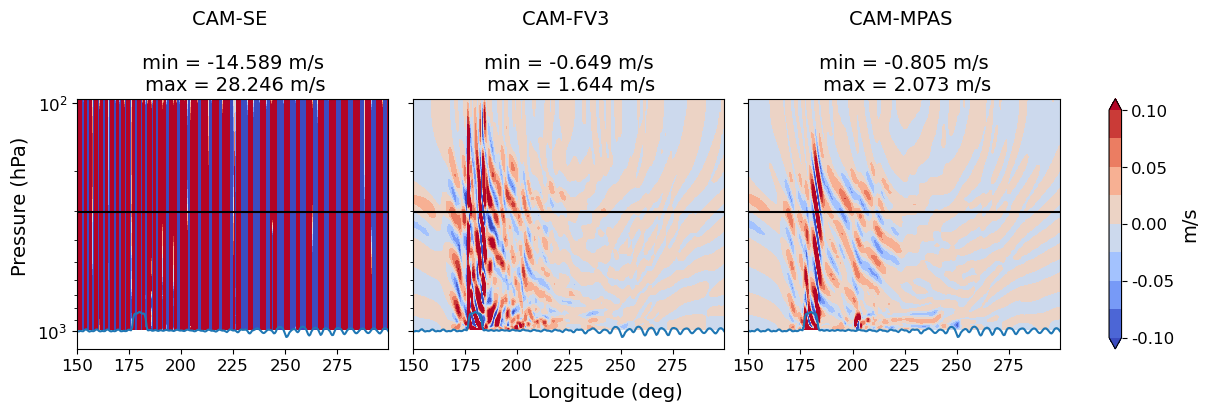

In [190]:
max1 = np.nanmax(field1)
max2 = np.nanmax(field2)
max3 = np.nanmax(field3)

min1 = np.nanmin(field1)
min2 = np.nanmin(field2)
min3 = np.nanmin(field3)

fig, axes = plt.subplots(1,3,figsize = (12,4), sharey=True, constrained_layout=True)
(ax1, ax2, ax3) = axes

minmin = -0.1
maxmax = 0.1
absmax = max(abs(minmin), abs(maxmax))
norm = colors.TwoSlopeNorm(vmin=minmin, vcenter=0, vmax=maxmax)
conts = np.linspace(minmin, maxmax, 9)
tick_range = np.linspace(minmin, maxmax, 5)
plot1 = ax1.contourf(LONGC1, P1, field1, levels = conts, cmap=cmap_choice, extend='both')
plot2 = ax2.contourf(LONGC2, P2, field2, levels = conts, cmap=cmap_choice, extend='both')
plot3 = ax3.contourf(LONGC3, P3, field3, levels = conts, cmap=cmap_choice, extend='both')
title = 'W'
cb_label = 'm/s'
unit = 'm/s'

cb = plt.colorbar(plot3,ax=axes,pad=0.05,shrink=1,format='%.2f', ticks = tick_range)
cb.ax.tick_params(labelsize=12)
cb.set_label('m/s', size=14)

ax1.set_yscale('log')
ax2.set_yscale('log')
ax3.set_yscale('log')

fig.supylabel('Pressure (hPa)', size=label_size)
fig.supxlabel('Longitude (deg)', size=label_size)

ax1.invert_yaxis()

# Plot the sponge layer start:
pc = 301.82
pc_low =552.4

ax1.plot(lon_crop, pc*np.ones_like(lon_crop), c='k')
ax2.plot(lon_crop, pc*np.ones_like(lon_crop), c='k')
ax3.plot(lon_crop, pc*np.ones_like(lon_crop), c='k')

# Add the surface topography:
ax1.plot(lon_crop, ps_t)
ax2.plot(lon_crop, ps_t)
ax3.plot(lon_crop, ps_t)

ax1.tick_params(axis='both', which='major', labelsize=12)
ax2.tick_params(axis='both', which='major', labelsize=12)
ax3.tick_params(axis='both', which='major', labelsize=12)

ax1.set_title(f'{dycore1} \n \n min = {min1:.3f} m/s \n max = {max1:.3f} m/s', size=label_size)
ax2.set_title(f'{dycore2} \n \n min = {min2:.3f} m/s \n max = {max2:.3f} m/s', size=label_size)
ax3.set_title(f'{dycore3} \n \n min = {min3:.3f} m/s \n max = {max3:.3f} m/s', size=label_size)

In [191]:
# What about interpolations onto z coordinates?
print(P1)
print(P3)

[[ 96.01718349  96.01718349  96.01718349 ...  96.01718349  96.01718349
   96.01718349]
 [101.88431566 101.88431566 101.88431566 ... 101.88431566 101.88431566
  101.88431566]
 [108.10995908 108.10995908 108.10995908 ... 108.10995908 108.10995908
  108.10995908]
 ...
 [970.79706258 970.79706258 970.79706258 ... 970.79706258 970.79706258
  970.79706258]
 [982.3813921  982.3813921  982.3813921  ... 982.3813921  982.3813921
  982.3813921 ]
 [994.10395514 994.10395514 994.10395514 ... 994.10395514 994.10395514
  994.10395514]]
[[ 95.97488971  95.97488971  95.97488971 ...  95.97488971  95.97488971
   95.97488971]
 [101.83943724 101.83943724 101.83943724 ... 101.83943724 101.83943724
  101.83943724]
 [108.06233806 108.06233806 108.06233806 ... 108.06233806 108.06233806
  108.06233806]
 ...
 [970.77998695 970.77998695 970.77998695 ... 970.77998695 970.77998695
  970.77998695]
 [982.36411297 982.36411297 982.36411297 ... 982.36411297 982.36411297
  982.36411297]
 [994.08647009 994.08647009 994.0

Text(0.5, 0.01, 'Longitude (deg)')

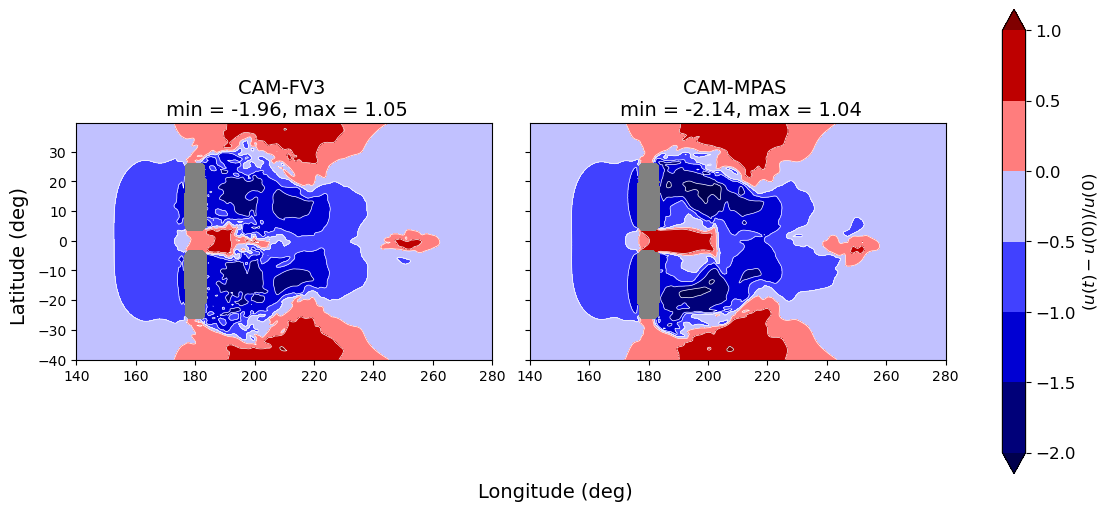

In [192]:
# Just FV3 and MPAS for Christiane's poster
fig, axes = plt.subplots(1,2, sharey=True, sharex=True, figsize = (11,5), layout="constrained")
(ax1, ax2) = axes

if rot:
    conts = np.linspace(-2.0, 2.0, 9)
    tick_range = np.linspace(-2.0, 2.0, 5)
    norm = colors.TwoSlopeNorm(vmin=-2.0, vcenter=0, vmax=2.0)
else:
    conts = np.linspace(-2.0, 1.0, 7)
    tick_range = np.linspace(-2.0, 1.0, 7)
    norm = colors.TwoSlopeNorm(vmin=-2.0, vcenter=0, vmax=1.0)
plot1 = ax1.contour(LON, LAT, U_field_vals2, levels = conts, linestyles='solid', colors='white', linewidths=0.5, norm=norm, extend = 'both')
plot2 = ax2.contour(LON, LAT, U_field_vals3, levels = conts, linestyles='solid', colors='white', linewidths=0.5, norm=norm, extend = 'both')
plot1 = ax1.contourf(LON, LAT, U_field_vals2, levels = conts, cmap=U_cmap, norm=norm, extend = 'both')
plot2 = ax2.contourf(LON, LAT, U_field_vals3, levels = conts, cmap=U_cmap, norm=norm, extend = 'both')

ax1.set_aspect('equal')
ax2.set_aspect('equal')

cb = plt.colorbar(plot2, ax=axes, ticks = tick_range, fraction=0.15)
cb.set_label(label='$(u(t) - u(0))/u(0)$', size=small_size)
cb.ax.tick_params(labelsize=12)

ax1.set_title(f'{dycore2} \n min = {np.round(U_min2,2)}, max = {np.round(U_max2,2)}', size=label_size)
ax2.set_title(f'{dycore3} \n min = {np.round(U_min3,2)}, max = {np.round(U_max3,2)}', size=label_size)

ax1.set_facecolor("grey")
ax2.set_facecolor("grey")

fig.supylabel('Latitude (deg)', size=label_size)
fig.supxlabel('Longitude (deg)', size=label_size)

Text(0.5, 0.01, 'Longitude (deg)')

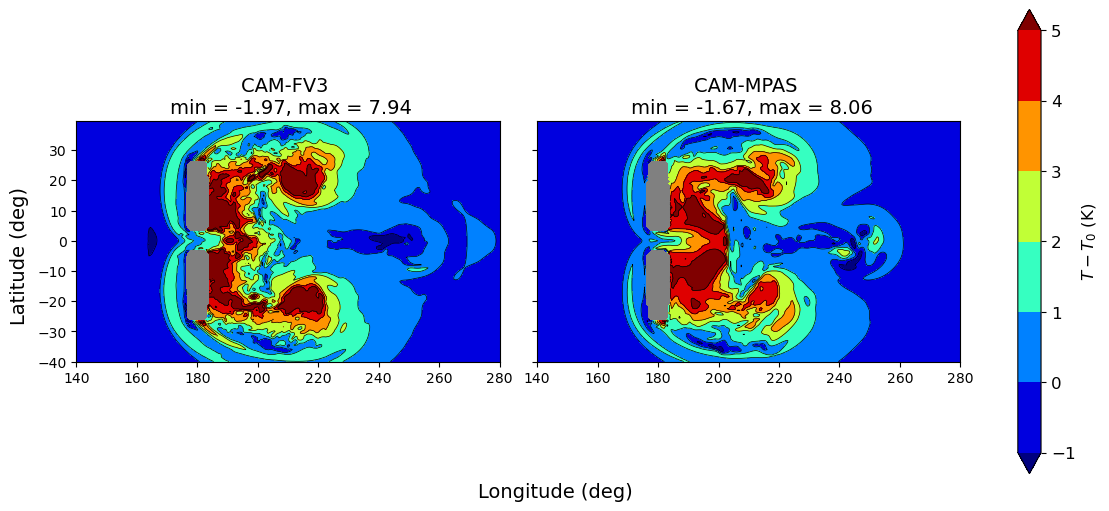

In [193]:
# Just FV3 and MPAS for Christiane's poster
fig, axes = plt.subplots(1,2, sharey=True, sharex=True, figsize = (11,5), layout="constrained")
(ax1, ax2) = axes

if rot:
    conts = np.linspace(-1, 5, 7)
    norm = colors.Normalize(vmin=-1, vmax=5)
    tick_range = np.linspace(-1, 5, 7)
else:
    conts = np.linspace(-1, 5, 7)
    norm = colors.Normalize(vmin=-1, vmax=5)
    tick_range = np.linspace(-1, 5, 7)

plot1 = ax1.contour(LON, LAT, T_field_vals2, levels = conts, linestyles='solid', colors='k', linewidths=0.5, norm=norm, extend = 'both')
plot2 = ax2.contour(LON, LAT, T_field_vals3, levels = conts, linestyles='solid', colors='k', linewidths=0.5, norm=norm, extend = 'both')
plot1 = ax1.contourf(LON, LAT, T_field_vals2, levels = conts, cmap=T_cmap, norm=norm, extend = 'both')
plot2 = ax2.contourf(LON, LAT, T_field_vals3, levels = conts, cmap=T_cmap, norm=norm, extend = 'both')

ax1.set_aspect('equal')
ax2.set_aspect('equal')

ax1.set_facecolor("grey")
ax2.set_facecolor("grey")

cb = plt.colorbar(plot2, ax=axes, ticks = tick_range, fraction=0.15)
cb.set_label(label='$T - T_0$ (K)', size=small_size)
cb.ax.tick_params(labelsize=12)

ax1.set_title(f'{dycore2} \n min = {np.round(T_min2,2)}, max = {np.round(T_max2,2)}', size=label_size)
ax2.set_title(f'{dycore3} \n min = {np.round(T_min3,2)}, max = {np.round(T_max3,2)}', size=label_size)

fig.supylabel('Latitude (deg)', size=label_size)
fig.supxlabel('Longitude (deg)', size=label_size)

IndexError: PS not found in /

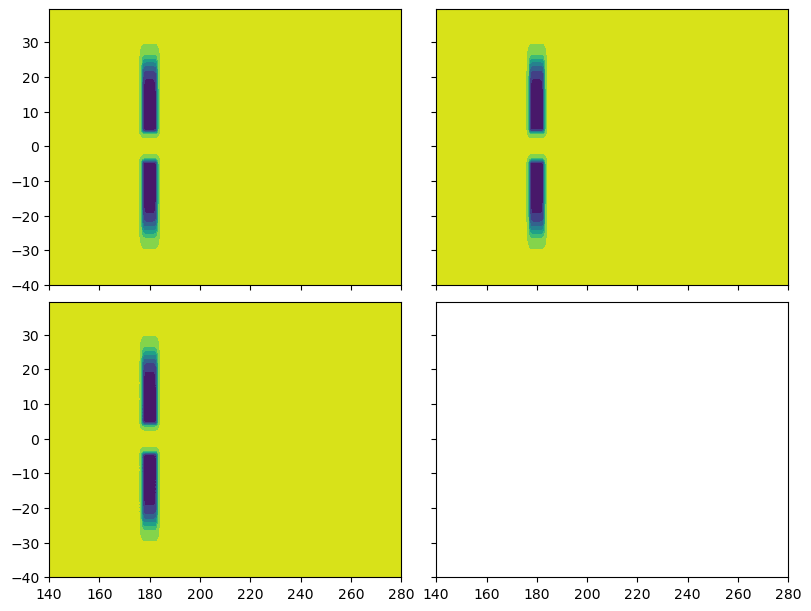

In [194]:
# Just plot contours of the surface pressure. Check that all of these agree!
fig, axes = plt.subplots(2,2, sharey=True, sharex=True, figsize = (8,6), layout="constrained")
(ax1, ax2), (ax3, ax4) = axes

plot1 = ax1.contourf(LON, LAT, nc1['PS'][0, lat_inds, lon_inds])
plot2 = ax2.contourf(LON, LAT, nc2['PS'][0, lat_inds, lon_inds])
plot3 = ax3.contourf(LON, LAT, nc3['PS'][0, lat_inds, lon_inds])
plot4 = ax4.contourf(LON, LAT, nc4['PS'][0, lat_inds, lon_inds])
plt.colorbar(plot4, ax=axes)

In [ ]:
fig, axes = plt.subplots(2,2, sharey=True, sharex=True, figsize = (8,6), layout="constrained")
(ax1, ax2), (ax3, ax4) = axes

print(np.min(nc1['Z3'][0, 0, lat_inds, lon_inds]))
print(np.max(nc1['Z3'][0, 0, lat_inds, lon_inds]))

plot1 = ax1.contourf(LON, LAT, nc1['Z3'][0, 0, lat_inds, lon_inds])
plot2 = ax2.contourf(LON, LAT, nc2['Z3'][0, 0, lat_inds, lon_inds])
plot3 = ax3.contourf(LON, LAT, nc3['Z3'][0, 0, lat_inds, lon_inds])
plot4 = ax4.contourf(LON, LAT, nc4['Z3'][0, 0, lat_inds, lon_inds])
plt.colorbar(plot4, ax=axes)